# 🌸 K-Means con Iris: guía paso a paso para principiantes

Este notebook te lleva de la mano por un flujo completo de clustering con K-Means usando el clásico dataset de Iris. Está documentado como si fuera tu primera vez con machine learning.

Objetivos:
- Entender qué es el clustering (agrupación no supervisada).
- Preparar datos y escalarlos correctamente.
- Elegir un número de clusters con el método del codo (Elbow).
- Entrenar K-Means y visualizar resultados.
- Interpretar la visualización y ajustar el número de clusters.

Nota importante: solo se agregan títulos, explicaciones y comentarios. ¡El código funcional no se modifica!

## 🎯 Objetivo del cuaderno
- Aprender a aplicar K-Means paso a paso y entender cada decisión (qué, por qué y para qué).
- Practicar con el dataset de Iris y sentar una base reutilizable para otros datos.

## 🧠 ¿Qué haremos y por qué?
1) Preparar datos numéricos y estandarizarlos → K-Means usa distancias; sin escalado, una variable podría dominar.
2) Elegir el número de clusters con Elbow → buscar el punto de rendimientos decrecientes.
3) Entrenar K-Means y visualizar → interpretar agrupaciones y centros.
4) Ajustar k si la separación no es clara → repetir con k alternativos.

## 🌍 ¿Para qué sirve esto en la vida real?
- Segmentar clientes por comportamiento (marketing, churn, recomendaciones).
- Agrupar productos por patrones de uso/venta.
- Detectar grupos naturales en sensores, finanzas o salud sin etiquetas.

## 🔷 ¿Qué es K-Means (explicación sencilla)?
- Algoritmo de agrupación no supervisada que busca k centros (centroides).
- Asigna cada punto al centro más cercano (por distancia euclídea).
- Repite: recalcula centros como la media de sus puntos y re-asigna hasta converger.

Ventajas: rápido, intuitivo, funciona bien en datos compactos y esféricos.
Limitaciones: exige elegir k; sensible a escala y outliers; no capta formas no esféricas.

## ✅ Qué obtendrás al final
- Un número de clusters razonable (k).
- Etiquetas de cluster para cada muestra y los centros (centroides).
- Un gráfico simple para comunicar resultados.

In [1]:
# Importamos las librerías que usaremos a lo largo del notebook
# - KMeans: algoritmo de clustering que agrupa puntos por similitud
# - StandardScaler: estandariza variables (media=0, desviación=1), crucial para KMeans
# - pandas: manejo de datos tabulares
# - matplotlib.pyplot: gráficos estáticos simples
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd 
from matplotlib import pyplot as plt


## 📘 Glosario rápido (conceptos y librerías)
- `Dataset`: tabla de datos. En Iris, cada fila es una flor; columnas son medidas.
- `Feature`: columna numérica usada por el modelo (ej. largo del pétalo).
- `Label`: columna objetivo (aquí `Species`), NO usada para entrenar K-Means.
- `K-Means`: agrupa puntos por cercanía en k clusters.
- `StandardScaler`: estandariza columnas (media 0, desvío 1).
- `Inertia (WCSS)`: suma de distancias al cuadrado dentro de cada cluster (menor es mejor).
- `Elbow`: método visual para elegir k donde WCSS deja de mejorar mucho.

## 📦 1) Librerías necesarias
Usamos:
- `pandas` para manejar datos en tablas (DataFrame).
- `scikit-learn` para el algoritmo K-Means y el escalado.
- `matplotlib` para visualizar.

Consejo: si aparece un error de importación, instala la librería con `pip install nombre_libreria` en tu entorno.

In [2]:
df_iris = pd.read_csv("Iris.csv")
df_iris.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 📥 2) Cargar el dataset Iris
Cargamos el archivo `Iris.csv` con pandas. Este dataset contiene medidas de flores de tres especies de iris.

Columnas típicas:
- SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm (numéricas)
- Species (la etiqueta real, pero aquí NO la usamos para entrenar K-Means).

In [3]:
X = df_iris.drop(columns='Species')
X.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,1,5.1,3.5,1.4,0.2
1,2,4.9,3.0,1.4,0.2
2,3,4.7,3.2,1.3,0.2
3,4,4.6,3.1,1.5,0.2
4,5,5.0,3.6,1.4,0.2


## 🧩 3) Selección de características (features)
Para clustering usamos solo variables numéricas. Aquí quitamos `Species` porque es la etiqueta verdadera y K-Means es no supervisado.

Resultado: `X` contiene solo las medidas numéricas de los pétalos y sépalos.

In [4]:
Scaler = StandardScaler()
X_scaled= Scaler.fit_transform(X)


## ⚖️ 4) Estandarización (StandardScaler)
K-Means usa distancias. Si una variable tiene valores más grandes que otra, dominará el cálculo y sesgará los clusters.
Por eso estandarizamos: cada columna queda con media 0 y desviación estándar 1.

In [5]:
X_scaled

array([[-1.72054204e+00, -9.00681170e-01,  1.03205722e+00,
        -1.34127240e+00, -1.31297673e+00],
       [-1.69744751e+00, -1.14301691e+00, -1.24957601e-01,
        -1.34127240e+00, -1.31297673e+00],
       [-1.67435299e+00, -1.38535265e+00,  3.37848329e-01,
        -1.39813811e+00, -1.31297673e+00],
       [-1.65125846e+00, -1.50652052e+00,  1.06445364e-01,
        -1.28440670e+00, -1.31297673e+00],
       [-1.62816394e+00, -1.02184904e+00,  1.26346019e+00,
        -1.34127240e+00, -1.31297673e+00],
       [-1.60506942e+00, -5.37177559e-01,  1.95766909e+00,
        -1.17067529e+00, -1.05003079e+00],
       [-1.58197489e+00, -1.50652052e+00,  8.00654259e-01,
        -1.34127240e+00, -1.18150376e+00],
       [-1.55888037e+00, -1.02184904e+00,  8.00654259e-01,
        -1.28440670e+00, -1.31297673e+00],
       [-1.53578584e+00, -1.74885626e+00, -3.56360566e-01,
        -1.34127240e+00, -1.31297673e+00],
       [-1.51269132e+00, -1.14301691e+00,  1.06445364e-01,
        -1.28440670e+00

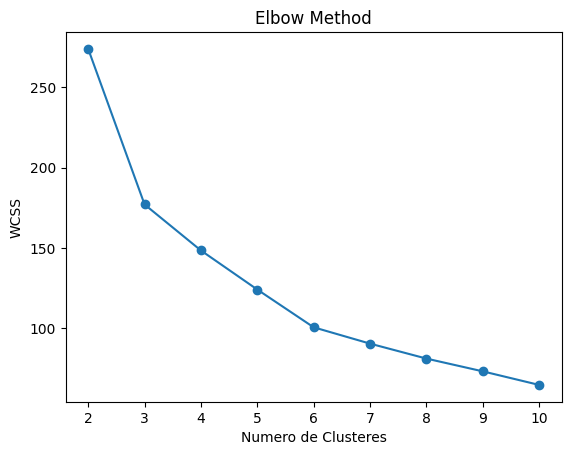

In [6]:
# ¿Cuantos grupos tengo que hacer?
# No sabemos los grupos, usar el metodo de Elbow y nos pone cuanta información hay en cada grupo

wcss = []
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter = 300, n_init = 10, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#Plot the Elbow
plt.plot(range(2,11), wcss, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Numero de Clusteres")
plt.ylabel("WCSS")
plt.show()

## 💪 5) ¿Cuántos clusters? Método del Codo (Elbow)
Entrenamos K-Means para varios valores de k y medimos la inercia (SSE: suma de distancias al cuadrado dentro de cada cluster).
Buscamos el "codo": el punto donde añadir más clusters apenas mejora la inercia.

Regla práctica: suele estar entre 2 y 6; aquí exploramos 2..10.

Me dice la ganancia que estamos consiguiendo al hacer cada grupo, cuando parece como un codo ahí miramos cual es el numero de cluster o grupos, acá usaremos 4

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


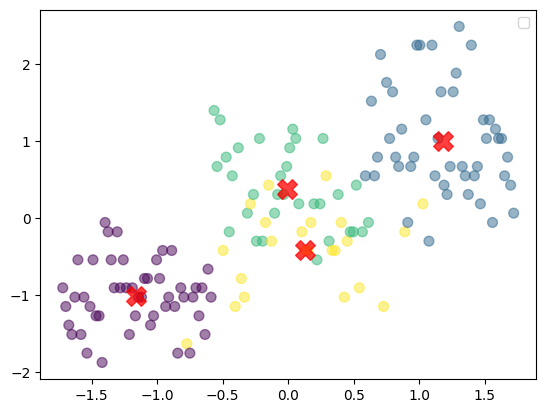

In [7]:
# Entrenamos K-Means con k=4 (hipótesis inicial por método del codo)
kmeans =  KMeans(n_clusters = 4, init = 'k-means++', max_iter= 300, n_init=10, random_state=0)
kmeans.fit(X_scaled)

# Etiquetas de cluster asignadas a cada muestra
cluster_labels = kmeans.labels_

# Visualización: scatter de las dos primeras features escaladas (solo 2D para simpleza)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels, cmap = "viridis", s= 50, alpha = 0.5)
# Centros de los clusters (también proyectados en las dos primeras dimensiones)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.legend()
plt.show()


## 🎯 6) Entrenar K-Means y visualizar resultados (k=4)
Entrenamos con k=4 (según la interpretación del codo anterior) y graficamos:
- Puntos: muestras escaladas (usamos solo las dos primeras columnas para un scatter 2D).
- Marcadores 'X' rojos: centros de los clusters.

Nota: esta proyección 2D no muestra toda la estructura de 4D, pero ayuda a intuir separaciones.

Vemos que con 4 cluster, el proceso se ve raro, es como si el centro estuviera muy junto y se pudiera asociar a 1 solo cluster

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


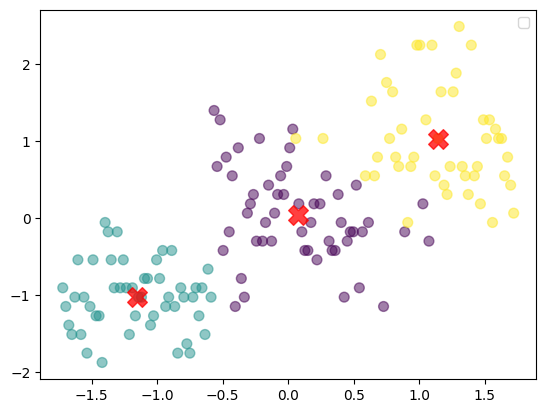

In [8]:
kmeans =  KMeans(n_clusters = 3, init = 'k-means++', max_iter= 300, n_init=10, random_state=0)
kmeans.fit(X_scaled)

cluster_labels = kmeans.labels_

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=cluster_labels, cmap = "viridis", s= 50, alpha = 0.5)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, alpha=0.75, marker='X')
plt.legend()
plt.show()

## 🔁 7) Ajuste: probar con k=3 clusters
Si los centros se ven demasiado juntos o la separación no es clara, reducimos a k=3.
Esto suele corresponder con las 3 especies de Iris, aunque aquí no usamos esas etiquetas para entrenar.

## ✅ 8) Conclusiones y siguientes pasos
- El método del codo ayuda a elegir k, pero conviene validar visualmente y con métricas como Silhouette.
- Estandarizar es esencial para K-Means porque usa distancias euclidianas.
- La visualización 2D es una proyección; para un análisis más fiel puedes usar PCA/TSNE.

Sugerencias (opcionales, sin cambiar tu código actual):
- Calcular Silhouette para k=2..6 y comparar.
- Probar PCA a 2D antes de graficar, para mejorar separación aparente.
- Comparar clusters con `Species` solo para validar (sin usarla al entrenar).

## 🧪 Cómo lo usarías en proyectos reales
- Preprocesa (limpieza de nulos, outliers, escalado).
- Prueba varios k y valida con Elbow y, opcional, Silhouette.
- Revisa tamaños de cluster (evita clusters diminutos).
- Interpreta centroides: qué valores altos/bajos caracterizan cada grupo.
- Documenta supuestos (p. ej. métricas usadas, escalado aplicado).

## 🧭 Interpretación de tu gráfico
- Puntos con colores: a qué cluster pertenece cada muestra.
- X rojas: ubicación de los centroides.
- Si muchos puntos distintos colores se mezclan, prueba otro k o agrega PCA para ver mejor.